# Fundamental Analysis
- 분석할 대상: IT(wics code: 45)
- 사용할 데이터
    - 글로벌 경제 분석 데이터: ./data/analysis/asset*.csv
    - IT 데이터: ./data/wics/*

## 0. 라이브러리 임포트

In [1]:
import os 
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# 경로 설정
BASE_ASSET   = os.path.join('data', 'analysis')
BASE_WICS    = os.path.join('data', 'wics')
OUT_DIR      = os.path.join('data', 'analysis/it')
os.makedirs(OUT_DIR, exist_ok=True)

wics_major_cd = 'G15'   # WICS IT 섹터 코드 prefix
wics_major_nm = "소재"

print('✅ 라이브러리 로딩 완료')

✅ 라이브러리 로딩 완료


## 2단계: IT와 글로벌 경제 요소들의 상관관계 분석 
- 어떤 요소들이 년도별 IT 산업 라이프사이클, 시장 규모, 성장 잠재력에 영향을 끼치는지 분석 

### 1. 글로벌 경제 통합 데이터 로딩 (asset_combined_close.csv)

In [2]:
from common.load import load_asset_data

# 1. 글로벌 자산 Close 데이터 로딩
close_path = os.path.join(BASE_ASSET, 'asset_combined_close.csv')
df_asset = load_asset_data(close_path)

print(f'글로벌 자산 데이터: {df_asset.shape}')
print(f'날짜 범위: {df_asset.index[0].date()} ~ {df_asset.index[-1].date()}')
print(f'컬럼: {list(df_asset.columns)}')
df_asset.tail(3)

글로벌 자산 데이터: (1280, 8)
날짜 범위: 2021-03-29 ~ 2026-03-27
컬럼: ['구리(HG=F)', '금(GC=F)', '반도체(SOX)', '석유(WTI)', '해운운임(BDI)', '미국10년국채(TNX)', '미국CPI_CPIAUCSL', '미국CPI_YoY']


,구리(HG=F),금(GC=F),반도체(SOX),석유(WTI),해운운임(BDI),미국10년국채(TNX),미국CPI_CPIAUCSL,미국CPI_YoY
Date,,,,,,,,
2026-03-25,5.5290,4549.799805,7967.750000,90.320000,10.00,4.328,NaN,NaN
2026-03-26,5.4465,4375.500000,7585.870117,94.480003,10.00,4.416,NaN,NaN
2026-03-27,5.4670,4492.000000,7457.669922,99.639999,9.93,4.440,NaN,NaN


### 2. IT 섹터 WICS 데이터 로딩 (2021~2026)

In [3]:
from common.load import load_wics_all_by_wics_major

df_wics = load_wics_all_by_wics_major(
    data_path="./data/wics/*", wics_major_cd=wics_major_cd)

print(f'\n통합 WICS 데이터: {df_wics.shape}')
print(f'날짜 범위: {df_wics["DATE"].min().date()} ~ {df_wics["DATE"].max().date()}')
df_wics[['IDX_CD','IDX_NM_KOR','CMP_CD','CMP_KOR','MKT_VAL','DATE']].head(3)

./data/wics\wics_company_2021.zip: G15 행 56,637
./data/wics\wics_company_2022.zip: G15 행 56,685
./data/wics\wics_company_2023.zip: G15 행 58,989
./data/wics\wics_company_2024.zip: G15 행 58,738
./data/wics\wics_company_2025.zip: G15 행 58,403
./data/wics\wics_company_2026.csv: G15 행 13,649

통합 WICS 데이터: (303101, 30)
날짜 범위: 2021-01-04 ~ 2026-03-27


,IDX_CD,IDX_NM_KOR,CMP_CD,CMP_KOR,MKT_VAL,DATE
0,G1510,WICS 소재,51910,LG화학,40164219,2021-01-04
1,G1510,WICS 소재,5490,POSCO홀딩스,16423384,2021-01-04
2,G1510,WICS 소재,9830,한화솔루션,4876507,2021-01-04


### 3. IT 업종 시가총액 시계열 (월별)

In [4]:
from common.analysis import get_capitalization_by_wics_major

df_cap = get_capitalization_by_wics_major(df_wics, wics_major_nm)


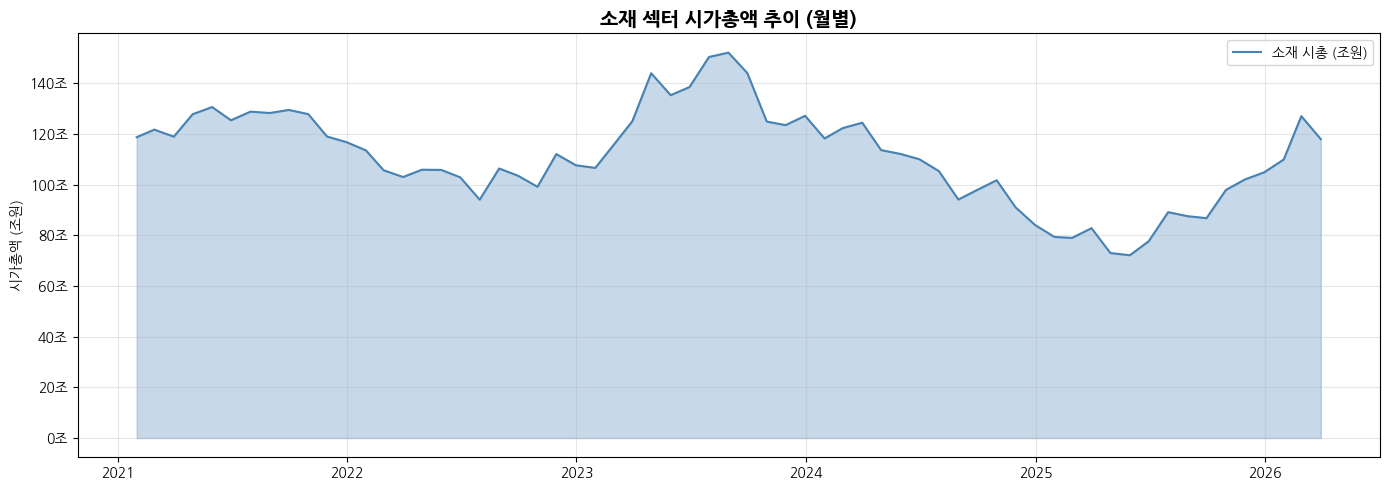

In [5]:
from common.plots import plot_capitalization_by_month

plot_capitalization_by_month(
  df_cap, wics_major_nm
)

### 4. IT 소분류별 시가총액 비중 (최신 날짜 기준)

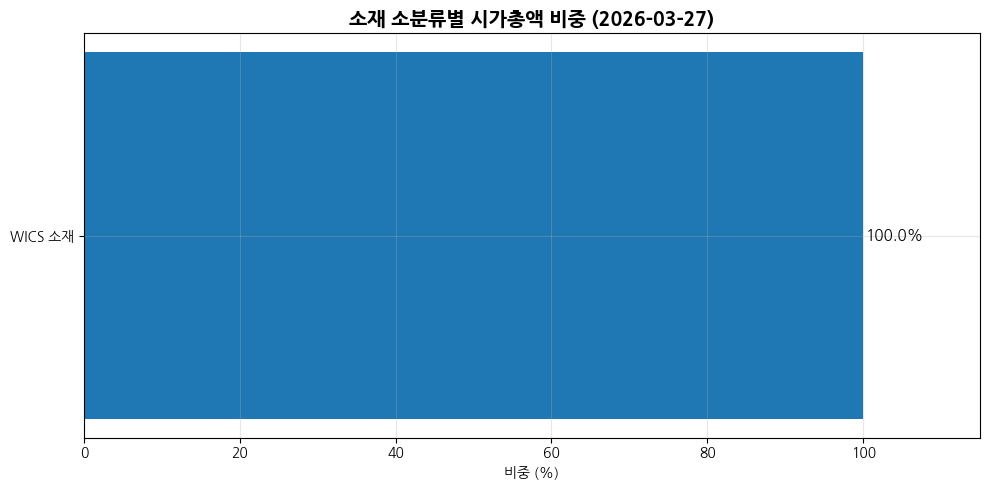

In [6]:
from common.plots import plot_capitalization_of_wics_medium_by_date

latest_date = df_wics['DATE'].max()
plot_capitalization_of_wics_medium_by_date(
  df_wics, latest_date, wics_major_nm
)

### 5. IT 시총 vs 글로벌 자산 상관관계 분석

In [7]:
from common.analysis import get_all_by_month

df_all = get_all_by_month(
  df_cap, df_asset, wics_major_nm
)

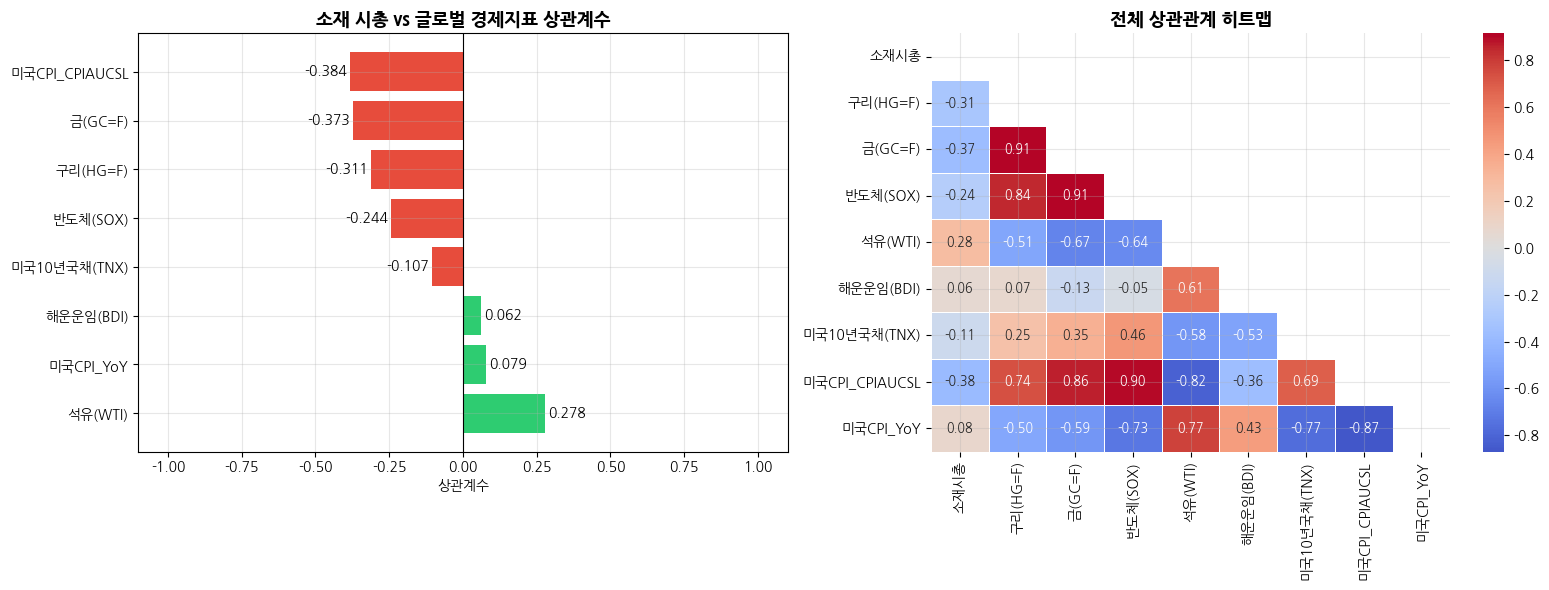

In [8]:
from common.plots import plot_corr_with_wics_major

plot_corr_with_wics_major(
  df_all, wics_major_nm
)

### 6. IT 시총 vs 주요 지표 산점도

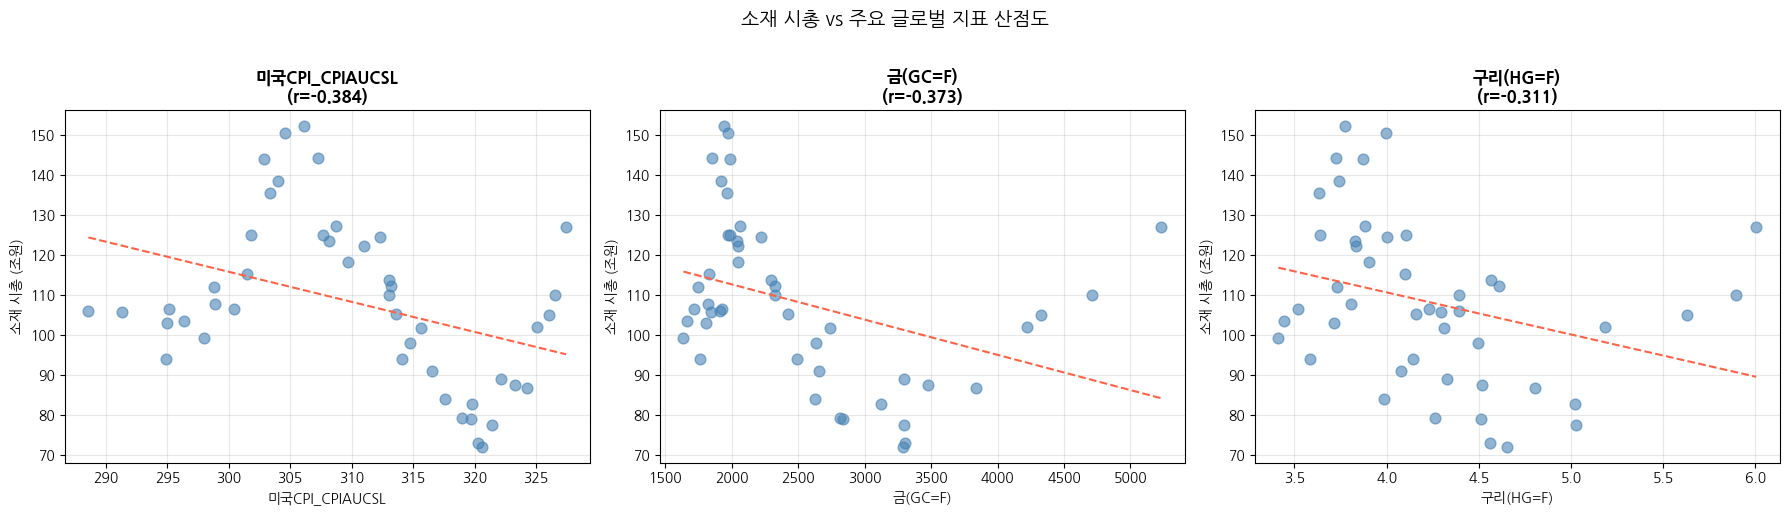

In [9]:
from common.plots import plot_corr_scatter_with_wics_major

plot_corr_scatter_with_wics_major(
    df_all, wics_major_nm
)

### 7. IT 시총 & 반도체(SOX) 추이 비교 (정규화)

In [10]:
from common.analysis import get_corr_with_wics_major

corr_with_wics_major = get_corr_with_wics_major(
    df_all, wics_major_nm
)
# 상관계수 상위 지표
top_indicators = corr_with_wics_major[corr_with_wics_major.abs() > 0.7].index.tolist()
top_indicators


[]

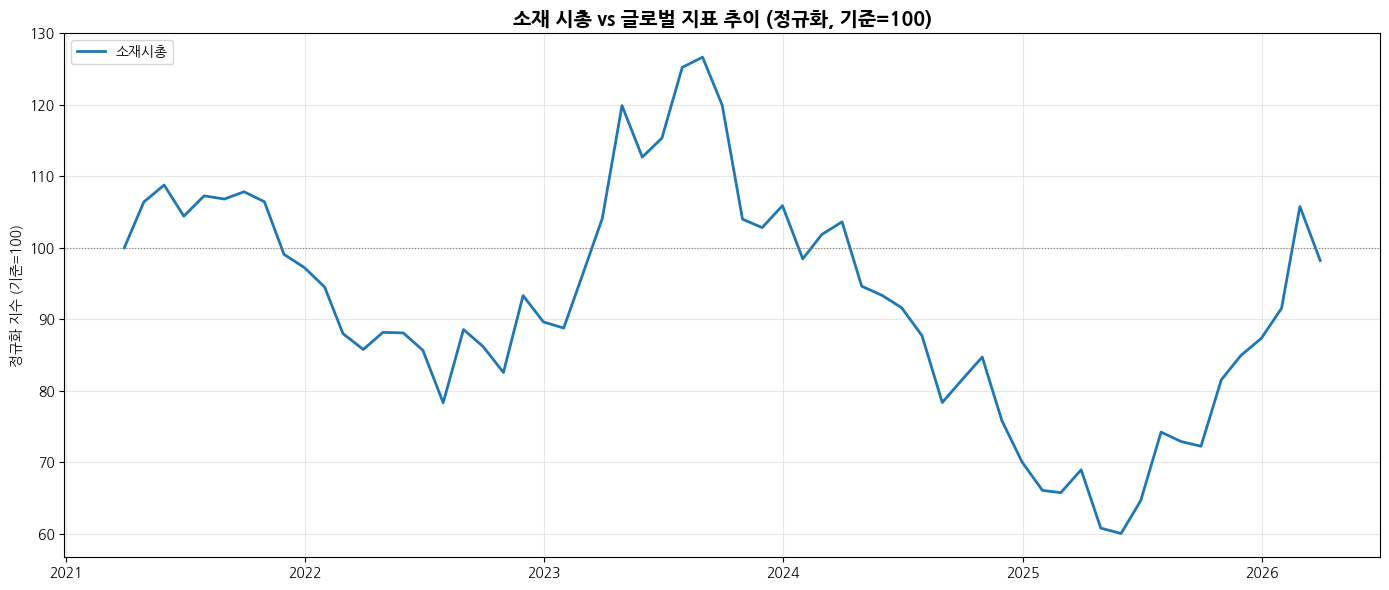

In [11]:
from common.plots import plot_norm_with_wics_major 

plot_norm_with_wics_major(
  df_all, df_asset, df_cap, top_indicators, wics_major_nm
)